# 04 — Next steps: filling the gaps

Companion notebook to `docs/02_what_is_missing.pdf`. Each section here matches one gap from that document and is meant to be run **after** the three existing notebooks have produced `data/cleaned/dpe_clean_model_ready.parquet`.

Sections:
1. Setup, paths, reusable preprocessor
2. Wider model menu (`make_model_zoo`) — Gap 2
3. Hyper-parameter tuning with `RandomizedSearchCV` — Gap 3
4. Richer evaluation (ROC, PR, calibration, residuals) — Gap 5
5. Permutation importance / SHAP — Gap 7
6. Leakage ablation on boosted models — Gap 8
7. Fair regression-vs-classification comparison — Gap 6
8. Class-imbalance experiments (SMOTE + threshold tuning) — Gap 4
9. Pick a champion per task, persist it — Gap 9
10. Presentation-ready figures — Gap 12
11. Export `requirements.txt` — Gap 10


## 1. Setup, paths, reusable preprocessor

In [11]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

DATA_PATH = Path("../data/cleaned/dpe_clean_model_ready.parquet")
REPORTS_DIR = Path("../reports/modeling")
MODELS_DIR = Path("../models")
FIG_DIR = Path("../figures/presentation")
for d in (REPORTS_DIR, MODELS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

TARGET_ERA = "construction_era"
TARGET_BINARY = "pre_post_1975"
TARGET_YEAR = "annee_construction"
DROP_COLS = [TARGET_ERA, TARGET_BINARY, TARGET_YEAR, "target_source", "split"]

df = pd.read_parquet(DATA_PATH)
print(f"Loaded {DATA_PATH}: {df.shape[0]:,} rows x {df.shape[1]} cols")

ALL_FEATURES = [c for c in df.columns if c not in DROP_COLS]
X = df[ALL_FEATURES].copy()
y_era = df[TARGET_ERA].astype(str)
y_binary = df[TARGET_BINARY].astype(str)
y_year = pd.to_numeric(df[TARGET_YEAR], errors="coerce")

train_mask = df["split"] == "train"
test_mask = df["split"] == "test"
X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_era_train, y_era_test = y_era.loc[train_mask], y_era.loc[test_mask]
y_binary_train, y_binary_test = y_binary.loc[train_mask], y_binary.loc[test_mask]

year_train = train_mask & y_year.notna()
year_test = test_mask & y_year.notna()
X_train_yr, X_test_yr = X.loc[year_train], X.loc[year_test]
y_year_train, y_year_test = y_year.loc[year_train], y_year.loc[year_test]

numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = [c for c in ALL_FEATURES if c not in numeric_features]
print(f"Numeric: {len(numeric_features)} | Categorical: {len(categorical_features)}")

try:
    _ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    _ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor(num_cols, cat_cols, scale=True):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", _ohe),
        ]), cat_cols),
    ], remainder="drop")

preprocessor = make_preprocessor(numeric_features, categorical_features)
preprocessor_tree = make_preprocessor(numeric_features, categorical_features, scale=False)


Loaded ../data/cleaned/dpe_clean_model_ready.parquet: 49,921 rows x 35 cols
Numeric: 14 | Categorical: 16


## 2. Wider model menu (Gap 2)

`make_model_zoo('classification')` and `make_model_zoo('regression')` return a `dict[str, Pipeline]` covering: dummy, logistic / ridge, KNN, decision tree, bagging, random forest, hist gradient boosting, SVM, MLP, polynomial ridge (regression), and XGBoost / LightGBM when available.


In [12]:
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingClassifier, BaggingRegressor,
    RandomForestClassifier, RandomForestRegressor,
    HistGradientBoostingClassifier, HistGradientBoostingRegressor,
)
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import PolynomialFeatures

def _has(mod):
    try:
        __import__(mod); return True
    except Exception:
        return False

HAS_XGB = _has("xgboost")
HAS_LGBM = _has("lightgbm")
print(f"xgboost available:  {HAS_XGB}")
print(f"lightgbm available: {HAS_LGBM}")

def make_model_zoo(task="classification"):
    """Return dict of name -> sklearn Pipeline for the given task."""
    assert task in ("classification", "regression")
    zoo = {}
    pre = preprocessor              # scaled (good for linear / SVM / MLP / KNN)
    pre_tree = preprocessor_tree    # unscaled (fine for trees)

    if task == "classification":
        zoo["dummy"] = Pipeline([("pre", pre_tree), ("m", DummyClassifier(strategy="most_frequent"))])
        zoo["logreg"] = Pipeline([("pre", pre), ("m", LogisticRegression(
            max_iter=2000, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["knn"] = Pipeline([("pre", pre), ("m", KNeighborsClassifier(n_neighbors=15, n_jobs=-1))])
        zoo["decision_tree"] = Pipeline([("pre", pre_tree), ("m", DecisionTreeClassifier(
            max_depth=12, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE))])
        zoo["bagging"] = Pipeline([("pre", pre_tree), ("m", BaggingClassifier(
            n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["random_forest"] = Pipeline([("pre", pre_tree), ("m", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2, class_weight="balanced_subsample",
            n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["hist_gb"] = Pipeline([("pre", pre_tree), ("m", HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE))])
        zoo["svm_rbf"] = Pipeline([("pre", pre), ("m", SVC(
            C=1.0, kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE))])
        zoo["mlp"] = Pipeline([("pre", pre), ("m", MLPClassifier(
            hidden_layer_sizes=(64, 32), max_iter=200, random_state=RANDOM_STATE))])
        if HAS_XGB:
            from xgboost import XGBClassifier
            zoo["xgboost"] = Pipeline([("pre", pre_tree), ("m", XGBClassifier(
                n_estimators=400, learning_rate=0.05, max_depth=6,
                tree_method="hist", eval_metric="mlogloss",
                random_state=RANDOM_STATE, n_jobs=-1))])
        if HAS_LGBM:
            from lightgbm import LGBMClassifier
            zoo["lightgbm"] = Pipeline([("pre", pre_tree), ("m", LGBMClassifier(
                n_estimators=400, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1))])
    else:
        zoo["dummy"] = Pipeline([("pre", pre_tree), ("m", DummyRegressor(strategy="mean"))])
        zoo["ridge"] = Pipeline([("pre", pre), ("m", Ridge(alpha=1.0, random_state=RANDOM_STATE))])
        zoo["polynomial_ridge"] = Pipeline([
            ("pre", pre),
            ("poly", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
            ("m", Ridge(alpha=10.0, random_state=RANDOM_STATE)),
        ])
        zoo["knn"] = Pipeline([("pre", pre), ("m", KNeighborsRegressor(n_neighbors=15, n_jobs=-1))])
        zoo["decision_tree"] = Pipeline([("pre", pre_tree), ("m", DecisionTreeRegressor(
            max_depth=12, min_samples_leaf=5, random_state=RANDOM_STATE))])
        zoo["bagging"] = Pipeline([("pre", pre_tree), ("m", BaggingRegressor(
            n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["random_forest"] = Pipeline([("pre", pre_tree), ("m", RandomForestRegressor(
            n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["hist_gb"] = Pipeline([("pre", pre_tree), ("m", HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE))])
        zoo["svr_rbf"] = Pipeline([("pre", pre), ("m", SVR(C=1.0, kernel="rbf"))])
        zoo["mlp"] = Pipeline([("pre", pre), ("m", MLPRegressor(
            hidden_layer_sizes=(64, 32), max_iter=200, random_state=RANDOM_STATE))])
        if HAS_XGB:
            from xgboost import XGBRegressor
            zoo["xgboost"] = Pipeline([("pre", pre_tree), ("m", XGBRegressor(
                n_estimators=400, learning_rate=0.05, max_depth=6,
                tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1))])
        if HAS_LGBM:
            from lightgbm import LGBMRegressor
            zoo["lightgbm"] = Pipeline([("pre", pre_tree), ("m", LGBMRegressor(
                n_estimators=400, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1))])
    return zoo

print("Classification zoo:", list(make_model_zoo("classification").keys()))
print("Regression zoo:    ", list(make_model_zoo("regression").keys()))


xgboost available:  False
lightgbm available: False
Classification zoo: ['dummy', 'logreg', 'knn', 'decision_tree', 'bagging', 'random_forest', 'hist_gb', 'svm_rbf', 'mlp']
Regression zoo:     ['dummy', 'ridge', 'polynomial_ridge', 'knn', 'decision_tree', 'bagging', 'random_forest', 'hist_gb', 'svr_rbf', 'mlp']


In [13]:
# Cross-validate the WHOLE zoo on Task A (era classification).
# Safer/faster scan: disable estimator internal parallelism and reduce cost for expensive models.
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone

# Build the zoo once
zoo = make_model_zoo("classification")

# Models we consider expensive for the quick scan
expensive_models = {"random_forest", "hist_gb", "xgboost", "lightgbm", "svm_rbf", "mlp", "bagging"}

rows = []
for name, pipe in zoo.items():
    print(f"CV: {name} ...", end=" ", flush=True)
    p = clone(pipe)
    # Defensive: set estimator n_jobs=1 where possible to avoid nested parallelism
    try:
        est = p.named_steps['m']
        if hasattr(est, 'n_jobs'):
            try:
                est.set_params(n_jobs=1)
            except Exception:
                est.n_jobs = 1
        # reduce complexity for quick scan
        if name == 'random_forest' and hasattr(est, 'n_estimators'):
            try: est.set_params(n_estimators=100)
            except Exception: pass
        if name == 'hist_gb' and hasattr(est, 'max_iter'):
            try: est.set_params(max_iter=100)
            except Exception: pass
        if name in ('xgboost','lightgbm') and hasattr(est, 'n_estimators'):
            try: est.set_params(n_estimators=200)
            except Exception: pass
    except Exception:
        pass

    folds = 3 if name in expensive_models else 5
    cv_local = StratifiedKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)
    s = cross_validate(p, X_train, y_era_train, cv=cv_local,
                       scoring=["accuracy", "f1_macro"], n_jobs=-1)
    rows.append({
        "model": name,
        "cv_accuracy_mean": s["test_accuracy"].mean(),
        "cv_accuracy_std": s["test_accuracy"].std(),
        "cv_macro_f1_mean": s["test_f1_macro"].mean(),
        "cv_macro_f1_std": s["test_f1_macro"].std(),
        "n_folds": folds,
    })
    print("done")

zoo_cv_era = pd.DataFrame(rows).sort_values("cv_macro_f1_mean", ascending=False)
zoo_cv_era.to_csv(REPORTS_DIR / "zoo_cv_era.csv", index=False)
zoo_cv_era



CV: dummy ... done
CV: logreg ... done
CV: knn ... done
CV: decision_tree ... done
CV: bagging ... done
CV: random_forest ... done
CV: hist_gb ... done
CV: svm_rbf ... done
CV: mlp ... 

/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


done


,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,n_folds
6,hist_gb,0.747972,0.003074,0.762278,0.002725,3
4,bagging,0.744992,0.001809,0.761909,0.002541,3
5,random_forest,0.743815,0.003061,0.757429,0.002095,3
7,svm_rbf,0.737104,0.001218,0.750504,0.000646,3
8,mlp,0.710261,0.005399,0.729664,0.004704,3
2,knn,0.703701,0.004718,0.713898,0.004938,5
1,logreg,0.654572,0.005014,0.669384,0.004047,5
3,decision_tree,0.650215,0.003577,0.668984,0.001903,5
0,dummy,0.269131,0.000070,0.070686,0.000015,5


## 3. Hyper-parameter tuning (Gap 3)

Small randomised search over the top tree-based models on Task A. Increase `n_iter` if you have more compute time.


In [14]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

tuning_grids = {
    "random_forest": {
        "m__n_estimators": randint(200, 600),
        "m__max_depth": [None, 10, 20, 30],
        "m__min_samples_leaf": randint(1, 10),
        "m__max_features": ["sqrt", 0.5, 0.8],
    },
    "hist_gb": {
        "m__max_iter": randint(150, 500),
        "m__learning_rate": uniform(0.02, 0.18),
        "m__max_depth": [None, 6, 8, 12],
        "m__l2_regularization": uniform(0.0, 1.0),
    },
}
if HAS_XGB:
    tuning_grids["xgboost"] = {
        "m__n_estimators": randint(200, 700),
        "m__learning_rate": uniform(0.02, 0.18),
        "m__max_depth": randint(4, 10),
        "m__subsample": uniform(0.6, 0.4),
        "m__colsample_bytree": uniform(0.6, 0.4),
    }

zoo = make_model_zoo("classification")
tuned = {}
tuning_rows = []
for name, grid in tuning_grids.items():
    print(f"Tuning {name} ...")
    rs = RandomizedSearchCV(zoo[name], grid, n_iter=12, cv=cv,
                            scoring="f1_macro", n_jobs=-1, random_state=RANDOM_STATE)
    rs.fit(X_train, y_era_train)
    tuned[name] = rs.best_estimator_
    tuning_rows.append({"model": name, "best_macro_f1": rs.best_score_,
                        "best_params": rs.best_params_})
    print(f"  best macro-F1 = {rs.best_score_:.4f}")
tuning_df = pd.DataFrame(tuning_rows).sort_values("best_macro_f1", ascending=False)
tuning_df.to_csv(REPORTS_DIR / "tuning_results.csv", index=False)
tuning_df


Tuning random_forest ...


/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  best macro-F1 = 0.7787
Tuning hist_gb ...


/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  best macro-F1 = 0.7820


,model,best_macro_f1,best_params
1,hist_gb,0.782003,"{'m__l2_regularization': 0.9832308858067882, '..."
0,random_forest,0.778731,"{'m__max_depth': 30, 'm__max_features': 'sqrt'..."


## 4. Richer evaluation (Gap 5)

Pick the best tuned model and produce: confusion matrix, per-class P/R/F1 bar chart, ROC + PR curves (binary task), calibration curve, predicted-vs-actual scatter (regression).


Champion (era) = hist_gb
              precision    recall  f1-score   support

   1948-1974       0.77      0.73      0.75      2660
   1975-1988       0.77      0.67      0.72      1439
   1989-2000       0.78      0.78      0.78       985
   2001-2012       0.84      0.88      0.86      1203
       2013+       0.91      0.91      0.91      1011
    pre-1948       0.71      0.78      0.75      2687

    accuracy                           0.78      9985
   macro avg       0.80      0.79      0.79      9985
weighted avg       0.78      0.78      0.77      9985



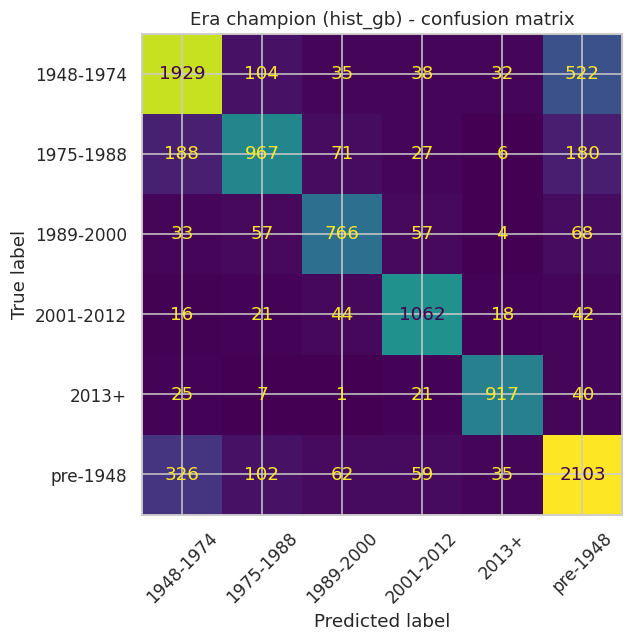

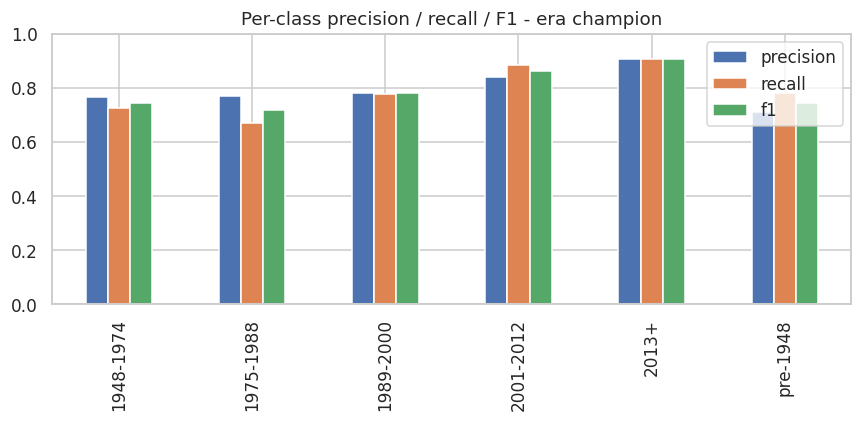

In [15]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_fscore_support, accuracy_score, f1_score,
    mean_absolute_error, r2_score,
)
from sklearn.calibration import CalibrationDisplay

best_name = tuning_df.iloc[0]["model"]
champion_era = tuned[best_name]
champion_era.fit(X_train, y_era_train)
y_pred_era = champion_era.predict(X_test)

print(f"Champion (era) = {best_name}")
print(classification_report(y_era_test, y_pred_era))

labels = sorted(y_era_test.unique())
cm = confusion_matrix(y_era_test, y_pred_era, labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=ax, xticks_rotation=45, values_format="d", colorbar=False)
ax.set_title(f"Era champion ({best_name}) - confusion matrix")
fig.tight_layout(); fig.savefig(FIG_DIR / "champion_era_confusion.png", dpi=140); plt.show()

prec, rec, f1, sup = precision_recall_fscore_support(y_era_test, y_pred_era, labels=labels)
metrics_df = pd.DataFrame({"precision": prec, "recall": rec, "f1": f1, "support": sup}, index=labels)
fig, ax = plt.subplots(figsize=(8, 4))
metrics_df[["precision", "recall", "f1"]].plot(kind="bar", ax=ax)
ax.set_title("Per-class precision / recall / F1 - era champion"); ax.set_ylim(0, 1)
fig.tight_layout(); fig.savefig(FIG_DIR / "champion_era_per_class.png", dpi=140); plt.show()


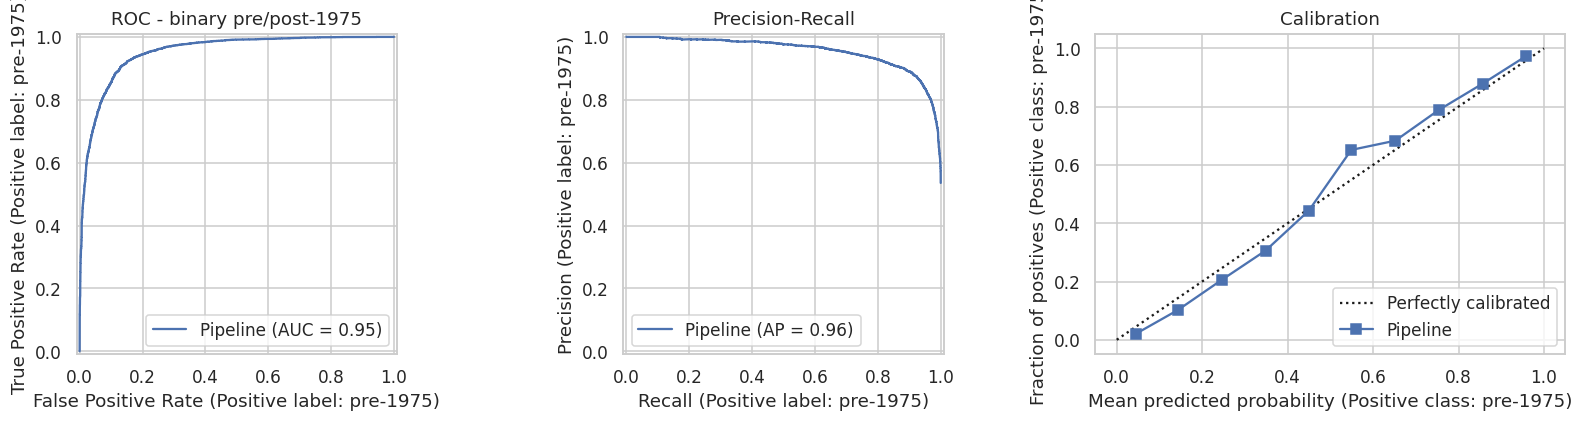

In [16]:
# Binary task: ROC, PR, calibration
champion_binary = Pipeline([("pre", preprocessor_tree),
    ("m", HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05,
                                         random_state=RANDOM_STATE))])
champion_binary.fit(X_train, y_binary_train)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
RocCurveDisplay.from_estimator(champion_binary, X_test, y_binary_test, ax=axes[0])
axes[0].set_title("ROC - binary pre/post-1975")
PrecisionRecallDisplay.from_estimator(champion_binary, X_test, y_binary_test, ax=axes[1])
axes[1].set_title("Precision-Recall")
CalibrationDisplay.from_estimator(champion_binary, X_test, y_binary_test, n_bins=10, ax=axes[2])
axes[2].set_title("Calibration")
fig.tight_layout(); fig.savefig(FIG_DIR / "champion_binary_curves.png", dpi=140); plt.show()


CV (reg): dummy ... MAE=25.61
CV (reg): ridge ... MAE=18.27
CV (reg): polynomial_ridge ... MAE=15.75
CV (reg): knn ... MAE=13.19
CV (reg): decision_tree ... MAE=15.74
CV (reg): bagging ... MAE=12.19
CV (reg): random_forest ... MAE=12.24
CV (reg): hist_gb ... MAE=15.26
CV (reg): svr_rbf ... MAE=15.95
CV (reg): mlp ... 

/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MAE=16.30

CV scan finished. Results saved to ../reports/modeling/zoo_cv_year.csv
Champion regressor: bagging MAE=12.19


/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


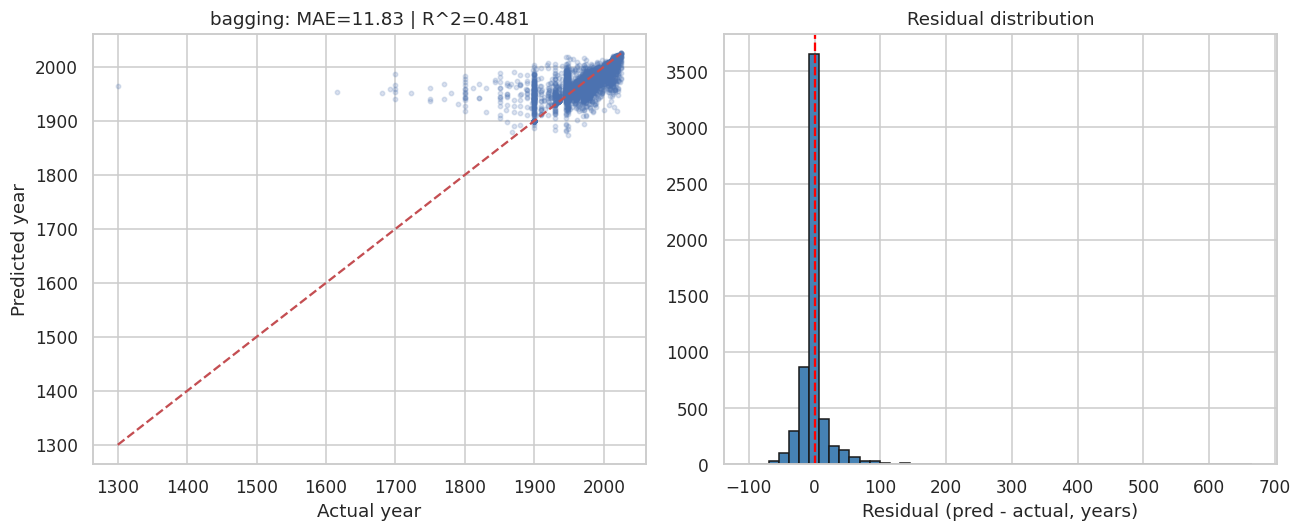

In [18]:
# Robust regression CV (sequential) + fit champion + diagnostics
from sklearn.model_selection import KFold, cross_validate
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Build regression zoo
reg_zoo = make_model_zoo("regression")

best_reg_name, best_reg_mae = None, np.inf
rows = []

# Models considered expensive for the quick scan
expensive_models = {"random_forest", "hist_gb", "xgboost", "lightgbm", "svr_rbf", "mlp", "bagging"}

for name, pipe in reg_zoo.items():
    print(f"CV (reg): {name} ...", end=" ", flush=True)
    p = clone(pipe)

    # Defensive: set estimator-level parallelism=1 and reduce complexity for quick scan
    try:
        est = p.named_steps["m"]
        if hasattr(est, "n_jobs"):
            try:
                est.set_params(n_jobs=1)
            except Exception:
                est.n_jobs = 1
        if name == "random_forest" and hasattr(est, "n_estimators"):
            try: est.set_params(n_estimators=100)
            except Exception: pass
        if name == "hist_gb" and hasattr(est, "max_iter"):
            try: est.set_params(max_iter=100)
            except Exception: pass
        if name in ("xgboost", "lightgbm") and hasattr(est, "n_estimators"):
            try: est.set_params(n_estimators=200)
            except Exception: pass
    except Exception:
        # no named_steps['m'] or unexpected shape — continue nevertheless
        pass

    folds = 3 if name in expensive_models else 5
    cv_local = KFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)

    try:
        # IMPORTANT: n_jobs=1 to avoid creating many worker processes / memory duplication
        s = cross_validate(p, X_train_yr, y_year_train,
                           cv=cv_local,
                           scoring="neg_mean_absolute_error",
                           n_jobs=1,
                           error_score="raise",
                           return_train_score=False)
    except Exception as e:
        print("FAILED during CV:", repr(e))
        rows.append({
            "model": name,
            "cv_mae_mean": np.nan,
            "cv_mae_std": np.nan,
            "n_folds": folds,
            "status": "failed",
            "error": str(e),
        })
        continue

    mae = -s["test_score"].mean()
    std = s["test_score"].std()
    rows.append({
        "model": name,
        "cv_mae_mean": mae,
        "cv_mae_std": std,
        "n_folds": folds,
        "status": "ok",
    })
    print(f"MAE={mae:.2f}")
    if mae < best_reg_mae:
        best_reg_mae, best_reg_name = mae, name

# Save scan results
zoo_cv_year = pd.DataFrame(rows).sort_values("cv_mae_mean")
zoo_cv_year.to_csv(REPORTS_DIR / "zoo_cv_year.csv", index=False)
print("\nCV scan finished. Results saved to", REPORTS_DIR / "zoo_cv_year.csv")
print("Champion regressor:", best_reg_name, f"MAE={best_reg_mae:.2f}")

# Fit champion and plot diagnostics
if best_reg_name is not None:
    champion = clone(reg_zoo[best_reg_name])
    champion.fit(X_train_yr, y_year_train)
    y_pred_year = champion.predict(X_test_yr)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(y_year_test, y_pred_year, alpha=0.2, s=8)
    lims = [min(y_year_test.min(), y_pred_year.min()),
            max(y_year_test.max(), y_pred_year.max())]
    axes[0].plot(lims, lims, "r--")
    axes[0].set_xlabel("Actual year"); axes[0].set_ylabel("Predicted year")
    axes[0].set_title(f"{best_reg_name}: MAE={mean_absolute_error(y_year_test, y_pred_year):.2f}"
                      f" | R^2={r2_score(y_year_test, y_pred_year):.3f}")

    axes[1].hist(y_pred_year - y_year_test, bins=50, color="steelblue", edgecolor="k")
    axes[1].axvline(0, color="red", linestyle="--")
    axes[1].set_xlabel("Residual (pred - actual, years)")
    axes[1].set_title("Residual distribution")

    fig.tight_layout()
    fig.savefig(FIG_DIR / "champion_year_scatter.png", dpi=140)
    plt.show()
else:
    print("No successful champion (all models failed CV).")

## 5. Permutation importance / SHAP (Gap 7)

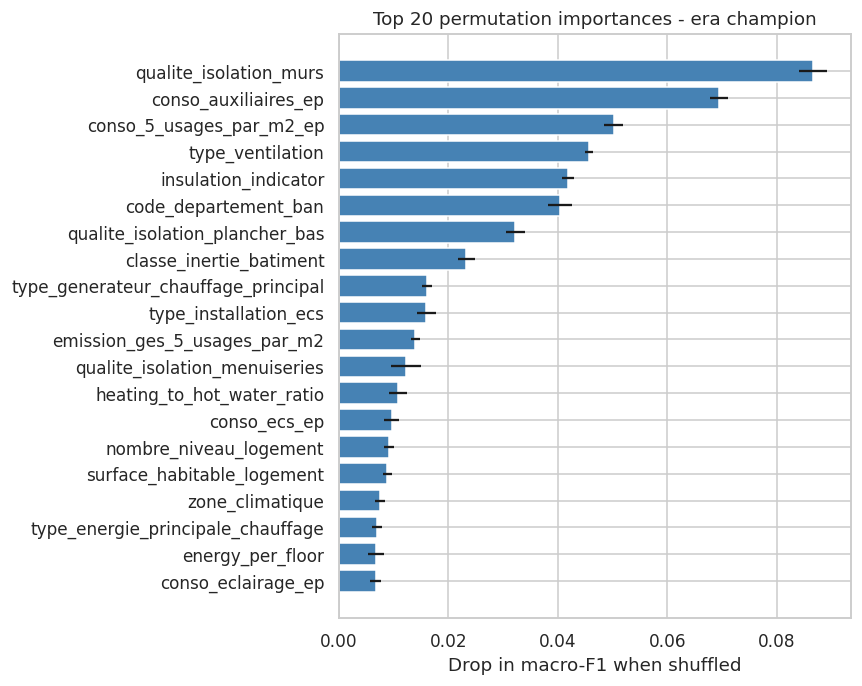

,feature,importance_mean,importance_std
12,qualite_isolation_murs,0.086622,0.002520
8,conso_auxiliaires_ep,0.069377,0.001650
0,conso_5_usages_par_m2_ep,0.050178,0.001757
18,type_ventilation,0.045686,0.000737
29,insulation_indicator,0.041855,0.001051
22,code_departement_ban,0.040358,0.002151
20,qualite_isolation_plancher_bas,0.032237,0.001725
21,classe_inertie_batiment,0.023298,0.001521
14,type_generateur_chauffage_principal,0.016090,0.000933
16,type_installation_ecs,0.015985,0.001717


In [19]:
from sklearn.inspection import permutation_importance

r = permutation_importance(champion_era, X_test, y_era_test,
                           n_repeats=5, random_state=RANDOM_STATE,
                           n_jobs=-1, scoring="f1_macro")
imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std,
}).sort_values("importance_mean", ascending=False)
imp.to_csv(REPORTS_DIR / "permutation_importance_era.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 0.32 * 20))
top = imp.head(20).iloc[::-1]
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"], color="steelblue")
ax.set_xlabel("Drop in macro-F1 when shuffled")
ax.set_title("Top 20 permutation importances - era champion")
fig.tight_layout(); fig.savefig(FIG_DIR / "permutation_importance.png", dpi=140); plt.show()
imp.head(20)


In [20]:
# Optional SHAP analysis (only runs if shap is installed and champion is tree-based)
try:
    import shap
    inner = champion_era.named_steps["m"]
    pre = champion_era.named_steps["pre"]
    Xt = pre.transform(X_test.sample(min(1000, len(X_test)), random_state=RANDOM_STATE))
    feat_names = pre.get_feature_names_out()
    explainer = shap.TreeExplainer(inner)
    sv = explainer.shap_values(Xt)
    shap.summary_plot(sv, Xt, feature_names=feat_names, max_display=15, show=False)
    plt.tight_layout(); plt.savefig(FIG_DIR / "shap_summary.png", dpi=140); plt.show()
except Exception as e:
    print("SHAP skipped:", e)


SHAP skipped: No module named 'shap'


## 6. Leakage ablation on boosted models (Gap 8)

In [21]:
LEAKY_FEATURES = ["type_generateur_chauffage_principal", "type_ventilation"]
ENERGY_FEATURES = [
    "conso_5_usages_par_m2_ep","emission_ges_5_usages_par_m2","etiquette_dpe","etiquette_ges",
    "conso_chauffage_ep","conso_ecs_ep","conso_refroidissement_ep",
    "conso_eclairage_ep","conso_auxiliaires_ep",
    "heating_to_hot_water_ratio","energy_per_floor",
]
GEO_FEATURES = ["code_departement_ban","zone_climatique","classe_altitude"]
STRUCTURAL_FEATURES = [c for c in ALL_FEATURES
                       if c not in ENERGY_FEATURES + GEO_FEATURES]

ablation_sets = {
    "energy_only": [c for c in ENERGY_FEATURES if c in ALL_FEATURES],
    "structural_only": [c for c in STRUCTURAL_FEATURES if c in ALL_FEATURES],
    "combined": ALL_FEATURES,
    "combined_minus_leaky": [c for c in ALL_FEATURES if c not in LEAKY_FEATURES],
}

models_to_check = {"random_forest": zoo["random_forest"], "hist_gb": zoo["hist_gb"]}
if HAS_XGB:
    models_to_check["xgboost"] = zoo["xgboost"]

rows = []
for set_name, cols in ablation_sets.items():
    num = [c for c in cols if c in numeric_features]
    cat = [c for c in cols if c in categorical_features]
    pre_local = make_preprocessor(num, cat, scale=False)
    for mname, pipe in models_to_check.items():
        local = Pipeline([("pre", pre_local), ("m", pipe.named_steps["m"])])
        s = cross_val_score(local, X_train[cols], y_era_train, cv=cv,
                            scoring="f1_macro", n_jobs=-1)
        rows.append({"feature_set": set_name, "model": mname,
                     "n_features": len(cols),
                     "macro_f1_mean": s.mean(), "macro_f1_std": s.std()})
        print(f"{set_name:>22} | {mname:>14} | F1={s.mean():.3f}+-{s.std():.3f}")
ablation_multi = pd.DataFrame(rows)
ablation_multi.to_csv(REPORTS_DIR / "feature_ablation_multi_model.csv", index=False)
ablation_multi.pivot(index="feature_set", columns="model", values="macro_f1_mean")


           energy_only |  random_forest | F1=0.624+-0.004
           energy_only |        hist_gb | F1=0.609+-0.006
       structural_only |  random_forest | F1=0.731+-0.002
       structural_only |        hist_gb | F1=0.741+-0.003
              combined |  random_forest | F1=0.764+-0.002
              combined |        hist_gb | F1=0.781+-0.001
  combined_minus_leaky |  random_forest | F1=0.757+-0.003
  combined_minus_leaky |        hist_gb | F1=0.767+-0.002


model,hist_gb,random_forest
feature_set,,
combined,0.781315,0.763754
combined_minus_leaky,0.767331,0.757260
energy_only,0.609151,0.623989
structural_only,0.741477,0.731169


## 7. Fair regression-vs-classification comparison (Gap 6)

Two protocols:
- **A**: restrict the classifier to the same rows that the regressor uses.
- **B**: take the regressor's predicted year and bucket it into eras, compare against the era target on the same rows.


In [25]:
# Fair comparison: Protocol A (era classifier on year-restricted rows) vs Protocol B (regression -> bucket -> era)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import Ridge
from sklearn.base import clone
from sklearn.metrics import f1_score, mean_absolute_error
import numpy as np
import pandas as pd

# Recompute/confirm year masks (use the same names used earlier in the notebook)
year_train = train_mask & y_year.notna()
year_test  = test_mask  & y_year.notna()

# Build consistent year-restricted datasets (X and y must have same number of rows)
X_train_yr = X.loc[year_train]
X_test_yr  = X.loc[year_test]
y_era_train_yr = y_era.loc[year_train]
y_era_test_yr  = y_era.loc[year_test]
y_year_train = y_year.loc[year_train]
y_year_test  = y_year.loc[year_test]

# Sanity checks
if len(X_train_yr) == 0 or len(X_test_yr) == 0:
    raise ValueError(
        f"Empty year-restricted split: train={len(X_train_yr)} test={len(X_test_yr)}.\n"
        "Make sure your `y_year` has non-null values and your `split` column is correct."
    )

if len(X_train_yr) != len(y_era_train_yr):
    raise ValueError(f"Mismatched train lengths: X={len(X_train_yr)} y_era={len(y_era_train_yr)}")

if len(X_test_yr) != len(y_era_test_yr):
    raise ValueError(f"Mismatched test lengths: X={len(X_test_yr)} y_era={len(y_era_test_yr)}")

# Era labels and helper
ERA_LABELS = ["pre-1948", "1948-1974", "1975-1988", "1989-2000", "2001-2012", "2013+"]
def year_to_era(y):
    if pd.isna(y):
        return "unknown"
    try:
        y = int(np.rint(y))
    except Exception:
        return "unknown"
    if y < 1948:  return "pre-1948"
    if y <= 1974: return "1948-1974"
    if y <= 1988: return "1975-1988"
    if y <= 2000: return "1989-2000"
    if y <= 2012: return "2001-2012"
    return "2013+"

# --- Protocol A: classifier on year-restricted rows ---
champion_era_restricted = Pipeline([
    ("pre", preprocessor_tree),
    ("m", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE)),
])
champion_era_restricted.fit(X_train_yr, y_era_train_yr)
y_pred_A = champion_era_restricted.predict(X_test_yr)
f1_A = f1_score(y_era_test_yr, y_pred_A, average="macro")

# --- Protocol B: regression -> bucket -> era ---
# Ensure champion_year exists or train a fallback
if 'champion_year' in globals():
    reg_model = champion_year
else:
    # try to use reg_zoo and best_reg_name if available
    if 'reg_zoo' in globals() and 'best_reg_name' in globals() and best_reg_name in reg_zoo:
        reg_model = clone(reg_zoo[best_reg_name])
        reg_model.fit(X_train_yr, y_year_train)
    else:
        # fallback simple Ridge pipeline
        reg_model = Pipeline([("pre", preprocessor), ("m", Ridge(alpha=1.0, random_state=RANDOM_STATE))])
        reg_model.fit(X_train_yr, y_year_train)

# Predict years and map to eras
y_pred_year_B = reg_model.predict(X_test_yr)
# round to nearest integer year before bucketing, keep NaNs if any
y_pred_year_round = np.where(pd.isna(y_pred_year_B), np.nan, np.rint(y_pred_year_B).astype(float))
y_pred_era_B = [year_to_era(y) for y in y_pred_year_round]

# Evaluate
f1_B = f1_score(y_era_test_yr, y_pred_era_B, average="macro")
mae_B = mean_absolute_error(y_year_test, y_pred_year_B)

# Save comparison
comp = pd.DataFrame([
    {"protocol": "A: classifier on year-restricted rows", "macro_f1": f1_A, "mae_years": np.nan},
    {"protocol": "B: regression -> bucket to era",         "macro_f1": f1_B, "mae_years": mae_B},
])
comp.to_csv(REPORTS_DIR / "fair_comparison_era.csv", index=False)
comp

,protocol,macro_f1,mae_years
0,A: classifier on year-restricted rows,0.796864,NaN
1,B: regression -> bucket to era,0.641693,11.826585


## 8. Class-imbalance experiments (Gap 4)

Three things: (a) `sample_weight` for HistGradientBoosting, (b) SMOTE inside the CV pipeline (if `imbalanced-learn` is installed), (c) threshold tuning for the binary task.


In [26]:
from sklearn.utils.class_weight import compute_sample_weight

# (a) sample weights for HistGB on Task A
sw = compute_sample_weight("balanced", y_era_train)
hgb = make_model_zoo("classification")["hist_gb"]
hgb.fit(X_train, y_era_train, m__sample_weight=sw)
print("HistGB + sample_weight macro-F1 (test):",
      f1_score(y_era_test, hgb.predict(X_test), average="macro"))

# (b) SMOTE pipeline (optional)
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTENC
    smote_pipe = ImbPipeline([
        ("pre", make_preprocessor(numeric_features, categorical_features, scale=False)),
        ("smote", SMOTENC(categorical_features="infer", random_state=RANDOM_STATE)),
        ("m", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE)),
    ])
    s = cross_val_score(smote_pipe, X_train, y_era_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    print(f"SMOTE + HistGB CV macro-F1 = {s.mean():.4f} +- {s.std():.4f}")
except Exception as e:
    print("SMOTE skipped:", e)

# (c) Threshold tuning on the binary task
proba = champion_binary.predict_proba(X_test)
classes = champion_binary.named_steps["m"].classes_
pos_idx = list(classes).index("post-1975") if "post-1975" in classes else 1
p_pos = proba[:, pos_idx]
best_t, best_f1 = 0.5, 0.0
for t in np.linspace(0.1, 0.9, 81):
    pred = np.where(p_pos >= t, "post-1975", "pre-1975")
    f1 = f1_score(y_binary_test, pred, average="macro")
    if f1 > best_f1:
        best_t, best_f1 = t, f1
default_f1 = f1_score(y_binary_test, champion_binary.predict(X_test), average="macro")
print(f"Default threshold 0.50 macro-F1 = {default_f1:.4f}")
print(f"Best threshold    {best_t:.2f} macro-F1 = {best_f1:.4f}")


HistGB + sample_weight macro-F1 (test): 0.782645697440652
SMOTE skipped: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/imblearn/pipeline.py", line 518, in fit
    Xt, yt = self._fit(X, y, routed_params, raw_params=params)
             ~~~~~~~~~^^^^^^

## 9. Pick champions per task, persist them (Gap 9)

In [28]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import Ridge
from sklearn.base import clone
from sklearn.metrics import f1_score, accuracy_score, mean_absolute_error, r2_score

# Ensure champion_era exists and is trained
if 'champion_era' not in globals():
    champion_era = Pipeline([
        ("pre", preprocessor_tree),
        ("m", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE)),
    ])
    champion_era.fit(X_train, y_era_train)
elif not hasattr(champion_era, "predict"):
    champion_era.fit(X_train, y_era_train)

# Ensure champion_binary exists and is trained
if 'champion_binary' not in globals():
    champion_binary = Pipeline([
        ("pre", preprocessor_tree),
        ("m", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE)),
    ])
    champion_binary.fit(X_train, y_binary_train)
elif not hasattr(champion_binary, "predict"):
    champion_binary.fit(X_train, y_binary_train)

# Ensure champion_year exists and is trained
if 'champion_year' not in globals():
    # Try to use reg_zoo and best_reg_name if available
    if 'reg_zoo' in globals() and 'best_reg_name' in globals() and best_reg_name in reg_zoo:
        champion_year = clone(reg_zoo[best_reg_name])
        champion_year.fit(X_train_yr, y_year_train)
    else:
        # fallback simple Ridge pipeline
        champion_year = Pipeline([
            ("pre", preprocessor),
            ("m", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
        ])
        champion_year.fit(X_train_yr, y_year_train)
elif not hasattr(champion_year, "predict"):
    champion_year.fit(X_train_yr, y_year_train)

results = []
y_pe = champion_era.predict(X_test)
results.append({
    "task": "era",
    "model": type(champion_era.named_steps["m"]).__name__,
    "metric": "macro_f1",
    "value": f1_score(y_era_test, y_pe, average="macro"),
    "secondary_accuracy": accuracy_score(y_era_test, y_pe)
})
y_pb = champion_binary.predict(X_test)
results.append({
    "task": "binary",
    "model": type(champion_binary.named_steps["m"]).__name__,
    "metric": "macro_f1",
    "value": f1_score(y_binary_test, y_pb, average="macro"),
    "secondary_accuracy": accuracy_score(y_binary_test, y_pb)
})
y_py = champion_year.predict(X_test_yr)
results.append({
    "task": "year",
    "model": type(champion_year.named_steps["m"]).__name__,
    "metric": "mae",
    "value": mean_absolute_error(y_year_test, y_py),
    "secondary_accuracy": r2_score(y_year_test, y_py)
})
champ_df = pd.DataFrame(results)
champ_df.to_csv(REPORTS_DIR / "champion_test_metrics.csv", index=False)
print(champ_df.to_string(index=False))

joblib.dump(champion_era,    MODELS_DIR / "champion_era.joblib")
joblib.dump(champion_binary, MODELS_DIR / "champion_binary.joblib")
joblib.dump(champion_year,   MODELS_DIR / "champion_year.joblib")
print("\nSaved:")
for p in sorted(MODELS_DIR.glob("*.joblib")):
    print(" -", p)


  task                          model   metric     value  secondary_accuracy
   era HistGradientBoostingClassifier macro_f1  0.792562            0.775563
binary HistGradientBoostingClassifier macro_f1  0.887318            0.888032
  year               BaggingRegressor      mae 11.826585            0.481026

Saved:
 - ../models/champion_binary.joblib
 - ../models/champion_era.joblib
 - ../models/champion_year.joblib


## 10. Presentation-ready figures (Gap 12)

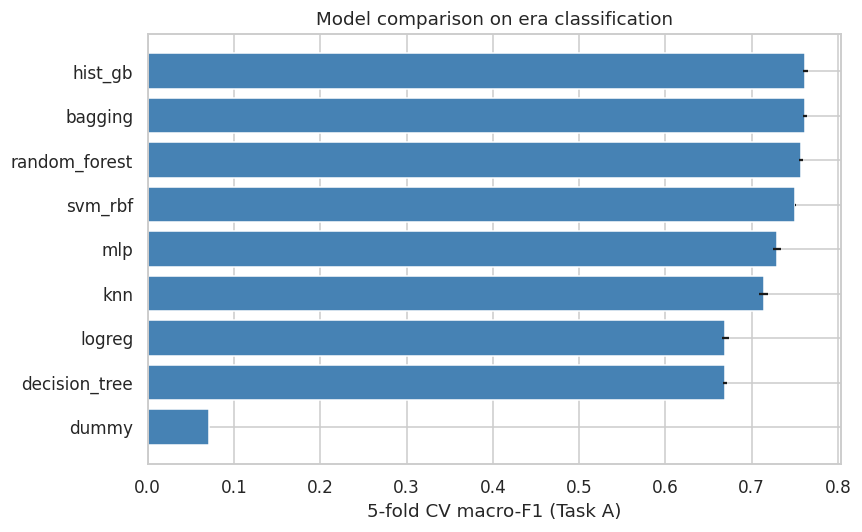

Presentation figures saved to ../figures/presentation
 - champion_binary_curves.png
 - champion_era_confusion.png
 - champion_era_per_class.png
 - champion_year_scatter.png
 - cv_macro_f1_zoo.png
 - permutation_importance.png


In [29]:
# Figure: CV macro-F1 of every model on Task A with error bars
fig, ax = plt.subplots(figsize=(8, 5))
d = zoo_cv_era.sort_values("cv_macro_f1_mean")
ax.barh(d["model"], d["cv_macro_f1_mean"], xerr=d["cv_macro_f1_std"], color="steelblue")
ax.set_xlabel("5-fold CV macro-F1 (Task A)")
ax.set_title("Model comparison on era classification")
fig.tight_layout(); fig.savefig(FIG_DIR / "cv_macro_f1_zoo.png", dpi=140); plt.show()

print("Presentation figures saved to", FIG_DIR)
for p in sorted(FIG_DIR.glob("*.png")):
    print(" -", p.name)


## 11. Export `requirements.txt` (Gap 10)

In [30]:
req = """pandas
numpy
scikit-learn>=1.3
scipy
matplotlib
seaborn
pyarrow
requests
joblib
# optional but recommended for sections 2-3, 6, 8
xgboost
lightgbm
imbalanced-learn
shap
"""
Path("../requirements.txt").write_text(req)
print("Wrote ../requirements.txt")


Wrote ../requirements.txt
